# Group Members:
Srimann Nambakkam sn29939,
Amaan Desai ad55777,
Walton Truelove wjt582

## Part 2.1 System Introduction:

## Part: 2.2 Euler Forward Test:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Problem parameters
lam = 5000.0  # Stiffness parameter (large = stiff!)

# Define the ODE: dy/dt = f(t, y), mechanical system with high damping
def f(t, x):    
    return -lam * x + 0.002 * np.sin(t)
                             
def x_exact(t):
    return 500*np.exp(-5000*t) + 4e-7 * np.sin(t)

Attempting Euler's Forward with h = 0.01...


<ipython-input-1-97ce28ce164b>:9: RuntimeWarning: overflow encountered in double_scalars
  return -lam * x + 0.002 * np.sin(t)
<ipython-input-2-7abd5f0f8160>:19: RuntimeWarning: invalid value encountered in double_scalars
  x[n+1] = x[n] + h * f(t[n], x[n])


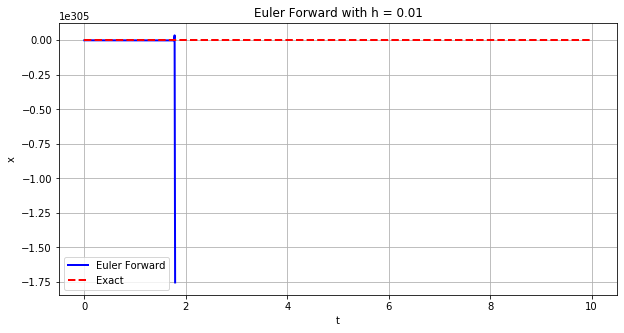

Maximum value reached: nan

Trying with h = 0.0001...


/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


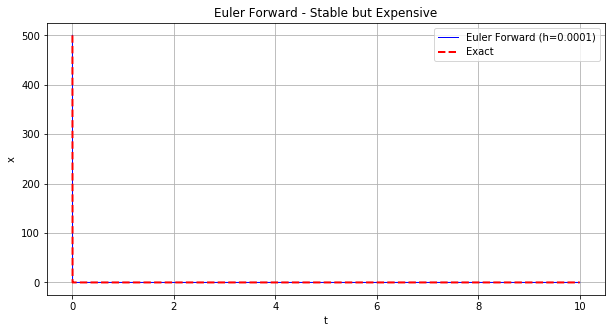

Number of steps needed: 100001
Maximum error: 5.89e+01


In [2]:
def euler_forward(f, x0, t0, t_final, h):
    """
    Euler's Forward method (explicit)

    y_{n+1} = y_n + h * f(t_n, y_n)

    Returns: arrays of time and solution
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    x = np.zeros(num_steps + 1)

    t[0] = t0
    x[0] = x0

    # Time stepping
    for n in range(num_steps):
        x[n+1] = x[n] + h * f(t[n], x[n])
        t[n+1] = t[n] + h

    return t, x
# Initial condition
x0 = 500.0
t0 = 0.0
t_final = 10.0

# Try Euler's Forward with h = 0.01
h_forward = 0.01
print(f"Attempting Euler's Forward with h = {h_forward}...")

try:
    t_forward, x_forward = euler_forward(f, x0, t0, t_final, h_forward)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(t_forward, x_forward, 'b-', label='Euler Forward', linewidth=2)
    plt.plot(t_forward, x_exact(t_forward), 'r--', label='Exact', linewidth=2)
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title(f'Euler Forward with h = {h_forward}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Maximum value reached: {np.max(np.abs(x_forward)):.2e}")
except:
    print("Solution blew up!")
# Try with MUCH smaller step size
h_forward_stable = 0.0001

print(f"\nTrying with h = {h_forward_stable}...")
t_forward, x_forward = euler_forward(f, x0, t0, t_final, h_forward_stable)

plt.figure(figsize=(10, 5))
plt.plot(t_forward, x_forward, 'b-', label=f'Euler Forward (h={h_forward_stable})', linewidth=1)
plt.plot(t_forward, x_exact(t_forward), 'r--', label='Exact', linewidth=2)
plt.xlabel('t')
plt.ylabel('x')
plt.title('Euler Forward - Stable but Expensive')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of steps needed: {len(t_forward)}")
print(f"Maximum error: {np.max(np.abs(x_forward - x_exact(t_forward))):.2e}")

In [3]:
# Stiffness ratio calculation
t_fast = lam # Fastest time scale from lambda = 5000
t_slow = 1 # slowest time scale from sin(t) term
print(f"Stiffness Ratio for the System: {t_fast/t_slow}")

Stiffness Ratio for the System: 5000.0


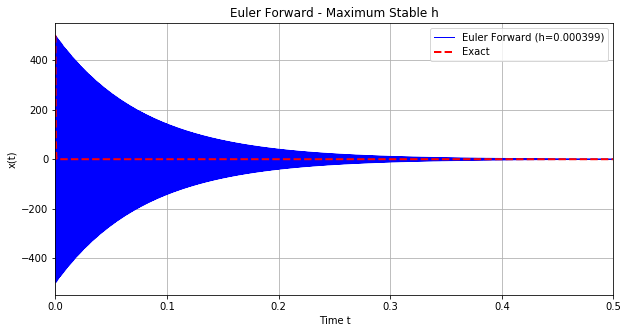

Number of steps needed: 25063
Maximum error: 5.66e+02


In [4]:
# Maximum stable step size calculation and steps needed
h_stable = 0.000399 # h < 2/|lam| for Euler's Forward Stability; 2/|lam| = 0.0004, so stable h is ~0.000399...
t_stable, x_stable = euler_forward(f, x0, t0, t_final, h_stable)

plt.figure(figsize=(10, 5))
plt.plot(t_stable, x_stable, 'b-', label=f'Euler Forward (h={h_stable})', linewidth=1)
plt.plot(t_stable, x_exact(t_stable), 'r--', label='Exact', linewidth=2)
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.xlim(0.0, 0.5)
plt.title('Euler Forward - Maximum Stable h')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of steps needed: {len(t_stable)}")
print(f"Maximum error: {np.max(np.abs(x_stable - x_exact(t_stable))):.2e}")

When initially testing with an already fairly small step size of h=0.01, Euler's forward blows up. Further testing with an even smaller value of h=0.0001 reaches stability, but at an extremely high computational cost of 100001 steps for a time interval from 0 to 10 seconds. This happens because this is a stiff system. The very high lambda value of -5000 followed by a slowly varying sine function results in a very fast transient period where x falls from 500 nearly to zero, followed by a very small sine wave. This abrupt change is very hard for Euler's forward to handle, meaning an extremely small step size is necessary for a stable solution. The stiffness ratio was then calculated to be 5000, further indicating a very stiff system. Additionally, the largest stable value of h for Euler's Forward is defined by the inequality h < 2/lambda. This was used to find that h must be less than 0.0004 in order to produce a stable solution for this system. Even then, with an h value of 0.00399, Euler's Forward still handles the transient part poorly, with a maximum error of over 560 despite eventually approaching stability for the dynamic part, and over 25000 steps necessary to reach a solution. As such, implicit methods will likely be far more effective for this system.

## Part 2.3 Backward Euler with Newton-Raphson Implementation:

### Defining the Residual Function:

In [5]:
def residual(x_next, x_n, t_next, h):
    """
    Residual function for implicit Euler.

    We want to solve: x_{n+1} = x_n + h * f(t_{n+1}, x_{n+1})

    Rearrange: g(x_{n+1}) = x_{n+1} - x_n - h*f(t_{n+1}, x_{n+1}) = 0

    Parameters:
    - x_next: the unknown x_{n+1} we're solving for
    - x_n: the known value at previous time step
    - t_next: time t_{n+1}
    - h: step size

    Returns: residual g(x_{n+1})
    """
    return x_next - x_n - h * f(t_next, x_next)
# Test the residual
t_test = 1.0
h_test = 0.1
x_n_test = x_exact(t_test)
x_next_test = x_exact(t_test + h_test)

g_test = residual(x_next_test, x_n_test, t_test + h_test, h_test)
print(f"Residual when using exact solution: {g_test:.2e}")
print("(Should be very close to zero)")

Residual when using exact solution: 1.99e-08
(Should be very close to zero)


In [6]:
def residual_derivative(h):
    """
    Derivative of residual with respect to x_{n+1}.

    For our problem: f(t,x) = -lambda*y + g(t)
    So: df/dy = -lambda

    Therefore: g'(x_{n+1}) = 1 - h*(df/dy) = 1 - h*(-lambda) = 1 + lambda*h

    This is CONSTANT for our problem!

    Parameters:
    - h: step size

    Returns: g'(x_{n+1})
    """
    df_dy = -lam  # For our specific problem
    return 1 - h * df_dy
# Verify with finite differences
def residual_derivative_numerical(x_next, x_n, t_next, h, eps=1e-8):
    """Numerical approximation of g' using finite differences"""
    return (residual(x_next + eps, x_n, t_next, h) - 
            residual(x_next - eps, x_n, t_next, h)) / (2 * eps)

# Test at a random point
x_test = 0.5
g_prime_analytical = residual_derivative(h_test)
g_prime_numerical = residual_derivative_numerical(x_test, x_n_test, t_test, h_test)

print(f"Analytical g': {g_prime_analytical:.6f}")
print(f"Numerical g':  {g_prime_numerical:.6f}")
print(f"Difference:    {abs(g_prime_analytical - g_prime_numerical):.2e}")

Analytical g': 501.000000
Numerical g':  501.000001
Difference:    9.52e-07


### Defining Newton-Raphson:

In [7]:
def newton_raphson_step(x_n, t_next, h, tol=1e-8, max_iter=20, verbose=False):
    """
    Solve for x_{n+1} using Newton-Raphson iteration.

    We want to find x_{n+1} such that g(x_{n+1}) = 0

    Newton-Raphson: x^(k+1) = x^(k) - g(x^(k)) / g'(x^(k))

    Parameters:
    - x_n: solution at previous time step
    - t_next: time t_{n+1}
    - h: step size
    - tol: convergence tolerance
    - max_iter: maximum iterations
    - verbose: print iteration details

    Returns: (x_{n+1}, number of iterations)
    """
    # Initial guess: use explicit Euler as predictor
    x_guess = x_n + h * f(t_next - h, x_n)  

    # Compute g' once (constant for our linear problem)
    g_prime = residual_derivative(h)

    if verbose:
        print(f"\n  Starting Newton-Raphson at t = {t_next:.4f}")
        print(f"  Initial guess: x = {x_guess:.6f}")
        print(f"  g'(constant) = {g_prime:.6f}\n")

    # Newton-Raphson iteration
    for k in range(max_iter):
        # Evaluate residual
        g = residual(x_guess, x_n, t_next, h)

        if verbose:
            print(f"  Iteration {k}: x = {x_guess:.6f}, g = {g:.2e}")
                   
        # Check convergence
        if abs(g) < tol:
            if verbose:
                print(f"Converged in {k} iteration(s)!\n")
            return x_guess, k
        
        # Newton-Raphson update     
        delta = -g / g_prime
        x_guess = x_guess + delta
        
    # Did not converge
    print(f"Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return y_guess, max_iter

# Test Newton-Raphson on one step
x_n = 1.0  # Initial condition
t_n = 0.0
h = 0.1

x_next, iters = newton_raphson_step(x_n, t_n + h, h, verbose=True)

print(f"Result: x({t_n + h}) = {x_next:.6f}")
print(f"Exact:  x({t_n + h}) = {x_exact(t_n + h):.6f}")
print(f"Error:  {abs(x_next - x_exact(t_n + h)):.2e}")


  Starting Newton-Raphson at t = 0.1000
  Initial guess: x = -499.000000
  g'(constant) = 501.000000

  Iteration 0: x = -499.000000, g = -2.50e+05
  Iteration 1: x = 0.001996, g = -6.24e-12
Converged in 1 iteration(s)!

Result: x(0.1) = 0.001996
Exact:  x(0.1) = 0.000000
Error:  2.00e-03


In [8]:
def euler_backward(f, x0, t0, t_final, h, tol=1e-8, verbose=True):
    """
    Euler's Backward (Implicit Euler) method with Newton-Raphson.

    For each time step:
    1. Solve x_{n+1} = x_n + h*f(t_{n+1}, x_{n+1}) using Newton-Raphson
    2. Move to next time step

    Parameters:
    - f: ODE function dy/dt = f(t, x)
    - x0: initial condition
    - t0, t_final: time span
    - h: step size
    - tol: Newton-Raphson tolerance
    - verbose_freq: print details every N steps (0 = no printing)

    Returns:
    - t: array of time points
    - x: array of solution values
    - iterations: array of NR iterations per step
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    x = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)

    # Initial condition
    t[0] = t0
    x[0] = x0

    # Time stepping loop
    for n in range(num_steps):
        # Solve for x_{n+1} using Newton-Raphson
        x[n+1], iterations[n] = newton_raphson_step(x[n], t[n] + h, h, tol=tol, verbose=False)
 
        t[n+1] = t[n] + h
        
    if(verbose==True):
        print(f"  Average NR iterations per step: {np.mean(iterations):.2f}")
        print(f"  Max NR iterations: {np.max(iterations)}")
        print(f"  Min NR iterations: {np.min(iterations)}\n")

    return t, x, iterations

TEST 1: h = 0.1
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1



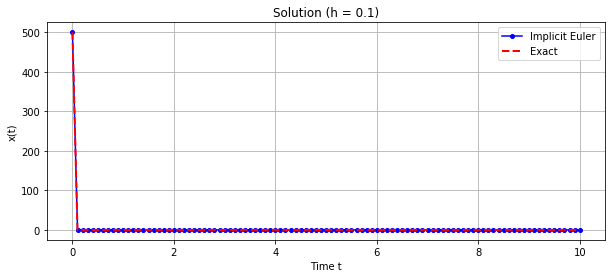

Maximum error: 9.98e-01
Number of steps: 101

TEST 2: h = 0.5
  Average NR iterations per step: 1.05
  Max NR iterations: 2
  Min NR iterations: 1



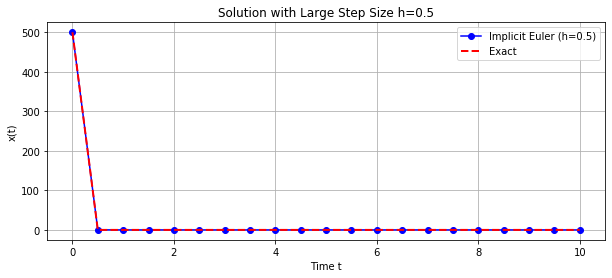

Maximum error: 2.00e-01
Number of steps: 21

TEST 3: h = 1.0
  Average NR iterations per step: 1.10
  Max NR iterations: 2
  Min NR iterations: 1



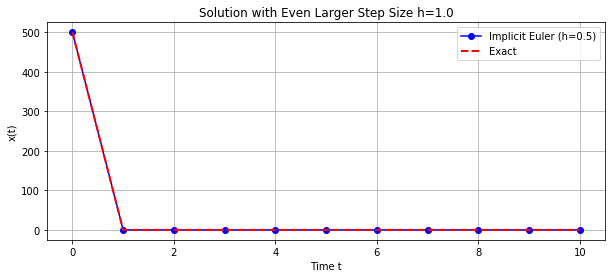

Maximum error: 2.00e-01
Number of steps: 21


In [9]:
# Test with different h values

print("TEST 1: h = 0.1")

h_backward = 0.1
t_backward, x_backward, iters = euler_backward(f, x0, t0, t_final, h_backward, verbose=True)

# Plot results
plt.figure(figsize=(10, 4))

# Solution comparison
plt.plot(t_backward, x_backward, 'b-o', markersize=4, label='Implicit Euler')
plt.plot(t_backward, x_exact(t_backward), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title(f'Solution (h = {h_backward})')
plt.legend()
plt.grid(True)
plt.show()

error = np.abs(x_backward - x_exact(t_backward))
print(f"Maximum error: {np.max(error):.2e}")
print(f"Number of steps: {len(t_backward)}")
print("")

print("TEST 2: h = 0.5")


h_large = 0.5
t_large, x_large, iters_large = euler_backward(f, x0, t0, t_final, h_large)

plt.figure(figsize=(10, 4))
plt.plot(t_large, x_large, 'b-o', markersize=6, label='Implicit Euler (h=0.5)')
plt.plot(t_large, x_exact(t_large), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title(f'Solution with Large Step Size h={h_large}')
plt.legend()
plt.grid(True)
plt.show()

error_large = np.abs(x_large - x_exact(t_large))
print(f"Maximum error: {np.max(error_large):.2e}")
print(f"Number of steps: {len(t_large)}")
print("")

print("TEST 3: h = 1.0")

h_largest = 1.0
t_largest, x_largest, iters_largest = euler_backward(f, x0, t0, t_final, h_largest)

plt.figure(figsize=(10, 4))
plt.plot(t_largest, x_largest, 'b-o', markersize=6, label='Implicit Euler (h=0.5)')
plt.plot(t_largest, x_exact(t_largest), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title(f'Solution with Even Larger Step Size h={h_largest}')
plt.legend()
plt.grid(True)
plt.show()

error_large = np.abs(x_large - x_exact(t_large))
print(f"Maximum error: {np.max(error_large):.2e}")
print(f"Number of steps: {len(t_large)}")

## Part 2.4 Stability Analysis and Comparison:

### Step Size Comparison:

In [15]:
h_stable_forward = 0.000399   # = ~0.000399  (stability limit: |1 + h*(-λ)| < 1)

steptable_configs = [
    ("Euler Forward (stable)", h_stable_forward, "forward"),
    ("Euler Forward (unstable)", 0.001,            "forward"),
    ("Euler Backward h=0.001",   0.001,  "backward"),
    ("Euler Backward h=0.1",     0.1,    "backward"),
    ("Euler Backward h=0.5",     0.5,    "backward"),
    ("Euler Backward h=1.0",     1.0,    "backward"),
]
print("Step Size Comparison Table")
print(f"{'Method':<30} {'~h':>8}  {'Steps':>7}  {'Stable?':>8}  {'Max Error':>12}")
print("-" * 65)

for label, h, method in steptable_configs:
    num_steps = int((t_final - t0) / h)
    if method == "forward":
        t_s, x_s = euler_forward(f, x0, t0, t_final, h)
        stable = np.all(np.isfinite(x_s)) and np.max(np.abs(x_s)) < 1e10
        err = np.max(np.abs(x_s - x_exact(t_s))) if stable else float('inf')
    else:
        t_s, x_s, _ = euler_backward(f, x0, t0, t_final, h, verbose=False)
        stable = True
        err = np.max(np.abs(x_s - x_exact(t_s)))
    print(f"{label:<30} {h:>8.4f}  {num_steps:>7d}  {'YES' if stable else 'NO':>8}  {err:>12.3e}")

print("-" * 65)
print(f"\nEuler Forward stability limit:  h < 2/λ ==> h < 2/{lam:.0f} ==> h < {2/lam:.2e}")
print(f"Euler Backward stability limit: All h > 0")


Step Size Comparison Table
Method                               ~h    Steps   Stable?     Max Error
-----------------------------------------------------------------
Euler Forward (stable)           0.0004    25062       YES     5.655e+02
Euler Forward (unstable)         0.0010    10000        NO           inf
Euler Backward h=0.001           0.0010    10000       YES     7.996e+01
Euler Backward h=0.1             0.1000      100       YES     9.980e-01
Euler Backward h=0.5             0.5000       20       YES     1.999e-01
Euler Backward h=1.0             1.0000       10       YES     9.998e-02
-----------------------------------------------------------------

Euler Forward stability limit:  h < 2/λ ==> h < 2/5000 ==> h < 4.00e-04
Euler Backward stability limit: All h > 0


<ipython-input-1-97ce28ce164b>:9: RuntimeWarning: overflow encountered in double_scalars
  return -lam * x + 0.002 * np.sin(t)
<ipython-input-2-7abd5f0f8160>:19: RuntimeWarning: invalid value encountered in double_scalars
  x[n+1] = x[n] + h * f(t[n], x[n])


### Computational Cost Comparison:

In [11]:
h_values_back = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]


print("Accuracy vs. Computational Cost for Euler's Backward")
print("-"*75)
print(f"{'h':>6}  {'Steps':>6}  {'Avg NR iters':>13}  {'Total f evals':>14}  {'Max Error':>12}")


backward_results = {}
for h in h_values_back:
    t_b, x_b, iters_b = euler_backward(f, x0, t0, t_final, h, verbose=False)
    num_steps = len(t_b) - 1
    avg_iters = np.mean(iters_b)
    total_f = int(np.sum(iters_b)) + num_steps   # NR iters + 1 guess per step
    max_err = np.max(np.abs(x_b - x_exact(t_b)))
    backward_results[h] = dict(steps=num_steps, avg_iters=avg_iters, total_f=total_f, err=max_err,t=t_b, x=x_b, iters=iters_b)
    print(f"{h:>6.3f}  {num_steps:>6d}  {avg_iters:>13.2f}  {total_f:>14d}  {max_err:>12.3e}")

# Euler Forward comparison row
t_fwd, x_fwd = euler_forward(f, x0, t0, t_final, h_stable_forward)
steps_fwd  = len(t_fwd) - 1
total_f_fwd = steps_fwd
err_fwd = np.max(np.abs(x_fwd - x_exact(t_fwd)))
print("-"*75)
print("Euler Forward with largest stable h:")
print(f"{h_stable_forward:>6}  {steps_fwd:>6d}  {'N/A':>13}  {total_f_fwd:>14d}  {err_fwd:>12.3e}")


Accuracy vs. Computational Cost for Euler's Backward
---------------------------------------------------------------------------
     h   Steps   Avg NR iters   Total f evals     Max Error
 0.001   10000           0.44           14371     7.996e+01
 0.010    1000           0.50            1500     9.804e+00
 0.050     200           0.98             397     1.992e+00
 0.100     100           1.00             200     9.980e-01
 0.500      20           1.05              41     1.999e-01
 1.000      10           1.10              21     9.998e-02
---------------------------------------------------------------------------
Euler Forward with largest stable h:
0.000399   25062            N/A           25062     5.655e+02


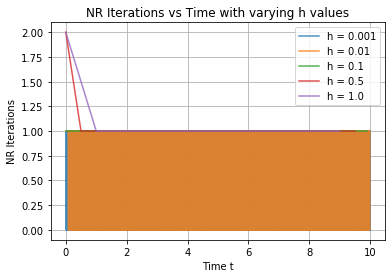

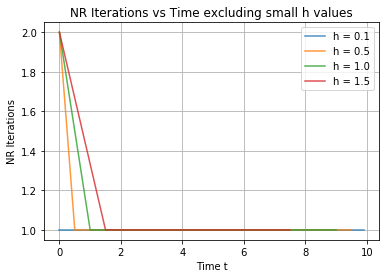

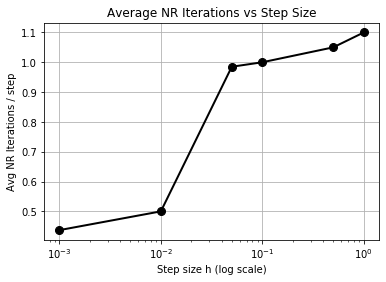

In [12]:

test_hs = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5]
larger_hs = [0.1, 0.5, 1.0, 1.5]

for h in (test_hs):
    t_b, x_b, iters_b = euler_backward(f, x0, t0, t_final, h, verbose=False)
    plt.plot(t_b[:-1], iters_b, label=f'h = {h}', alpha=0.8)
plt.xlabel('Time t'); plt.ylabel('NR Iterations')
plt.title('NR Iterations vs Time with varying h values')
plt.legend()
plt.grid(True)
plt.show()

for h in (larger_hs):
    t_b, x_b, iters_b = euler_backward(f, x0, t0, t_final, h, verbose=False)
    plt.plot(t_b[:-1], iters_b, label=f'h = {h}', alpha=0.8)
plt.xlabel('Time t'); plt.ylabel('NR Iterations')
plt.title('NR Iterations vs Time excluding small h values')
plt.legend()
plt.grid(True)
plt.show()

hs_plot = sorted(backward_results.keys())
avg_iters_plot = [backward_results[h]['avg_iters'] for h in hs_plot]
plt.semilogx(hs_plot, avg_iters_plot, 'ko-', markersize=8, linewidth=2)
plt.xlabel('Step size h (log scale)'); plt.ylabel('Avg NR Iterations / step')
plt.title('Average NR Iterations vs Step Size')
plt.grid(True)


plt.show()


### Solution Quality:

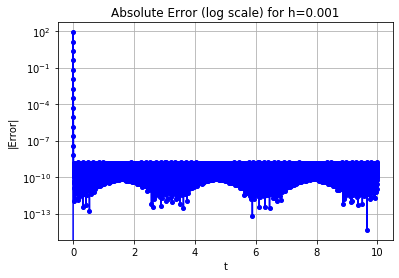

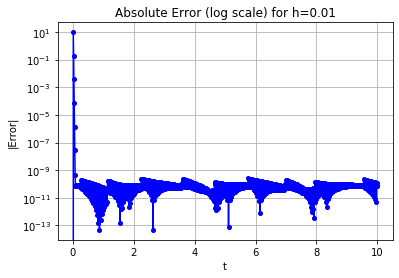

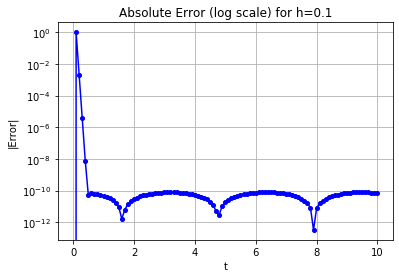

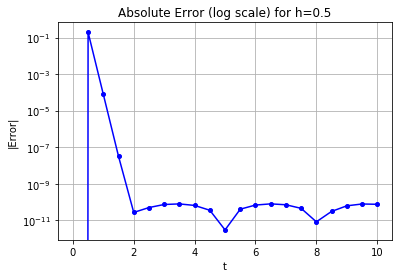

In [13]:
# Error Plotting
error_hs = [0.001, 0.01, 0.1, 0.5]

for h in (error_hs):
    t_backward, x_backward, iters = euler_backward(f, x0, t0, t_final, h, verbose=False)
    error = np.abs(x_backward - x_exact(t_backward))
    plt.semilogy(t_backward, error, 'b-o', markersize=4)
    plt.xlabel('Time t')
    plt.ylabel('|Error|')
    plt.title(f'Absolute Error (log scale) for h={h}')
    plt.grid(True)
    plt.show()

In [16]:
# Verification that Solution remains within bounds
print("Verifying Solutions remain within Reasonable Physical Bounds...")
h = 0.1
t_backward, x_backward, iters = euler_backward(f, x0, t0, t_final, h, verbose=False)
if np.min(x_backward<-5) or np.max(x_backward>500): # While system could oscillate below zero, it should not shoot off towards negative infinity, nor should it exceed the initial value of x=500
    print("Error: Euler's Backward Solution does not remain within reasonable physical bounds!")
else:
    print("Euler's Backward Solution remains within reasonable physical bounds!")
x_analytical = x_exact(t_backward)
if np.min(x_analytical<-5) or np.max(x_analytical>500): # While system could oscillate below zero, it should not shoot off towards negative infinity, nor should it exceed the initial value of x=500
    print("Error: Analytical Solution does not remain within reasonable physical bounds!")
else:
    print("Analytical Solution remains within reasonable physical bounds!")

Verifying Solutions remain within Reasonable Physical Bounds...
Euler's Backward Solution remains within reasonable physical bounds!
Analytical Solution remains within reasonable physical bounds!


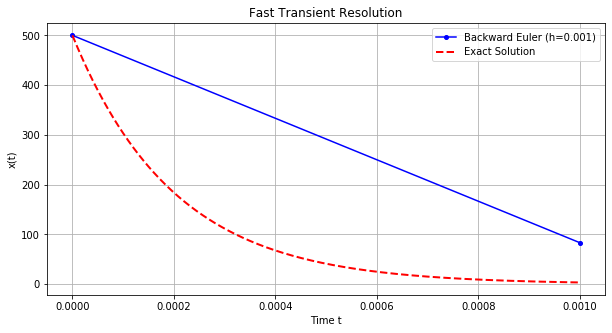

In [17]:
# Checking that fast transients are resolved correctly
t_b, x_b, _ = euler_backward(f, x0, t0, t_final, h=0.001, verbose=False)
t_dense = np.linspace(0, 0.001, 500)
transient = t_b <= 0.001

plt.figure(figsize=(10, 5))
plt.plot(t_b[transient], x_b[transient], 'b-o', markersize=4, label='Backward Euler (h=0.001)')
plt.plot(t_dense, x_exact(t_dense), 'r--', linewidth=2, label='Exact Solution')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title('Fast Transient Resolution')
plt.legend()
plt.grid(True)
plt.show()

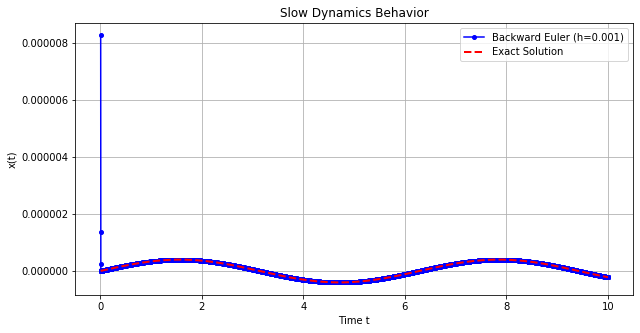

In [18]:
# Checking slow dynamics
t_b, x_b, _ = euler_backward(f, x0, t0, t_final, h=0.001, verbose=False)
t_dense = np.linspace(0.01, t_final, 2000)
slow_dynamics = t_b >= 0.01

plt.figure(figsize=(10,5))
plt.plot(t_b[slow_dynamics], x_b[slow_dynamics], 'b-o', markersize=4, label='Backward Euler (h=0.001)')
plt.plot(t_dense, x_exact(t_dense), 'r--', linewidth=2, label='Exact Solution')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title('Slow Dynamics Behavior')
plt.legend()
plt.grid(True)
plt.show()